# 1、ChatMessageHistory的使用

场景一：记忆存储

In [1]:
from langchain_classic.memory import ChatMessageHistory
# 1、ChatMessageHistory实例化

history = ChatMessageHistory()

# 2、添加相关消息进行存储

history.add_user_message("你好")
history.add_ai_message("很高兴认识你，我叫小e")

# 3、打印存储的消息
print(history.messages)

[HumanMessage(content='你好', additional_kwargs={}, response_metadata={}), AIMessage(content='很高兴认识你', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]


场景二：对接大模型

In [5]:
from langchain_openai import ChatOpenAI
import os
import dotenv

dotenv.load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["OPENAI_BASE_URL"] = os.getenv("OPENAI_BASE_URL")

# 创建大模型实例
chat_model = ChatOpenAI(
    model = "gpt-4o-mini"
)
history.add_user_message("你好我是小明")
history.add_ai_message("我是小e，一个人工智能助手")
history.add_user_message("我叫什么")

response = chat_model.invoke(history.messages)
print(response.content)

你刚刚提到你叫小明。


# 2、ConversationBufferMemory的使用

场景一：以字符串方式返回存储的信息

In [8]:
from langchain_classic.memory import ConversationBufferMemory

# 1、实例化
memory = ConversationBufferMemory()

# 2、存储信息 inputs对应用户消息 outputs对应ai消息
memory.save_context(inputs={"input":"你好，我叫夏雪"},outputs = {"output":"很高兴认识你"})
memory.save_context(inputs={"input":"帮我回答1+2"},outputs = {"output":"3"})

# 3、获取存储的信息
print(memory.load_memory_variables({})) # 返回的字典结构的key叫history

{'history': 'Human: 你好，我叫夏雪\nAI: 很高兴认识你\nHuman: 帮我回答1+2\nAI: 3'}


场景一：以消息列表方式返回存储的信息

In [10]:
from langchain_classic.memory import ConversationBufferMemory

# 1、实例化
memory = ConversationBufferMemory(return_messages=True)

# 2、存储信息 inputs对应用户消息 outputs对应ai消息
memory.save_context(inputs={"input":"你好，我叫夏雪"},outputs = {"output":"很高兴认识你"})
memory.save_context(inputs={"input":"帮我回答1+2"},outputs = {"output":"3"})

# 3、获取存储的信息
print(memory.load_memory_variables({})) # 返回的消息列表结构的key叫history
print('\n')
print(memory.chat_memory.messages) # 返回消息列表的另一种方式

{'history': [HumanMessage(content='你好，我叫夏雪', additional_kwargs={}, response_metadata={}), AIMessage(content='很高兴认识你', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='帮我回答1+2', additional_kwargs={}, response_metadata={}), AIMessage(content='3', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]}


[HumanMessage(content='你好，我叫夏雪', additional_kwargs={}, response_metadata={}), AIMessage(content='很高兴认识你', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='帮我回答1+2', additional_kwargs={}, response_metadata={}), AIMessage(content='3', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]


场景三：结合大模型与提示词模版(prompttemplate)

In [13]:
from langchain_core.prompts import PromptTemplate
from langchain_classic.chains import LLMChain
chat_model = ChatOpenAI(
    model = "gpt-4o-mini"
)

prompt_template = PromptTemplate.from_template(
    template = """
        你可以与人类对话。
        当前对话: {history}
        人类问题: {question}
        回复：
    """
)
# 提供memory实例
memory = ConversationBufferMemory()
# 提供chain
chain = LLMChain(llm = chat_model,prompt = prompt_template,memory=memory)

response  = chain.invoke({"question":"1+1=？"})
print(response)

{'question': '1+1=？', 'history': '', 'text': '1 + 1 = 2。'}


In [18]:
response = chain.invoke({"question":"我刚才的问题是什么？"})
print(response)

{'question': '我刚才的问题是什么？', 'chat_history': 'Human: 1+1=？\nAI: 1+1=2。\nHuman: 我刚才的问题是什么？\nAI: 你刚才的问题是“1+1=？”', 'text': '你刚才的问题是“我刚才的问题是什么？”'}


场景四：基于三，显式设置memory的key值

In [16]:
from langchain_core.prompts import PromptTemplate
from langchain_classic.chains import LLMChain
chat_model = ChatOpenAI(
    model = "gpt-4o-mini"
)

prompt_template = PromptTemplate.from_template(
    template = """
        你可以与人类对话。
        当前对话: {chat_history}
        人类问题: {question}
        回复：
    """
)
# 提供memory实例
memory = ConversationBufferMemory(memory_key="chat_history") # 通过memory_key修改memory数据的变量名
# 提供chain
chain = LLMChain(llm = chat_model,prompt = prompt_template,memory=memory)

response  = chain.invoke({"question":"1+1=？"})
print(response)

{'question': '1+1=？', 'chat_history': '', 'text': '1+1=2。'}


In [17]:
response = chain.invoke({"question":"我刚才的问题是什么？"})
print(response)

{'question': '我刚才的问题是什么？', 'chat_history': 'Human: 1+1=？\nAI: 1+1=2。', 'text': '你刚才的问题是“1+1=？”'}


场景五：使用ChatPromptTemplate

In [19]:
# 1.导入相关包
from langchain_core.messages import SystemMessage
from langchain_classic.chains.llm import LLMChain
from langchain_classic.memory import ConversationBufferMemory
from langchain_core.prompts import MessagesPlaceholder,ChatPromptTemplate,HumanMessagePromptTemplate
from langchain_openai import ChatOpenAI
# 2.创建LLM
llm = ChatOpenAI(model='gpt-4o-mini')
# 3.创建Prompt
prompt = ChatPromptTemplate.from_messages([
    ("system","你是一个与人类对话的机器人。"),
    MessagesPlaceholder(variable_name='history'),# 消息列表
    ("human","问题：{question}")
])
# 4.创建Memory
memory = ConversationBufferMemory(return_messages=True)
# 5.创建LLMChain
llm_chain = LLMChain(prompt=prompt,llm=llm, memory=memory)
# 6.调用LLMChain
res1 = llm_chain.invoke({
    "question": "中国首都在哪里？"
})
print(res1,end="\n\n")
res2 = llm_chain.invoke({
    "question": "我刚刚问了什么"
})
print(res2)

{'question': '中国首都在哪里？', 'history': [HumanMessage(content='中国首都在哪里？', additional_kwargs={}, response_metadata={}), AIMessage(content='中国的首都是北京。', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])], 'text': '中国的首都是北京。'}

{'question': '我刚刚问了什么', 'history': [HumanMessage(content='中国首都在哪里？', additional_kwargs={}, response_metadata={}), AIMessage(content='中国的首都是北京。', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='我刚刚问了什么', additional_kwargs={}, response_metadata={}), AIMessage(content='你刚刚问了“中国首都在哪里？”', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])], 'text': '你刚刚问了“中国首都在哪里？”'}


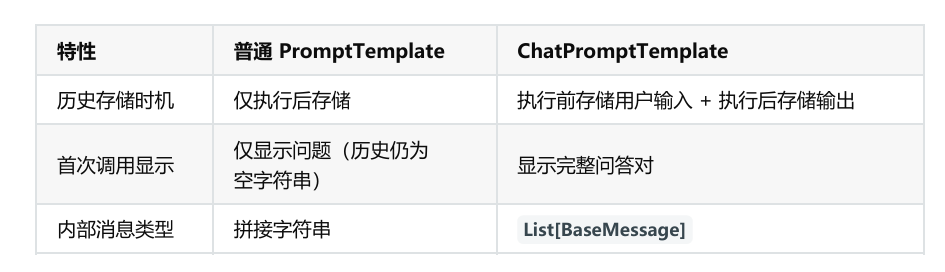

# 3、ConversationChain的使用

实际上是就是对ConversationBufferMemory和LLMChain进行了封装

示例1：以PromptTemplat为例

In [21]:
from langchain_classic.chains.conversation.base import ConversationChain
from langchain_core.prompts import PromptTemplate
from langchain_classic.chains import LLMChain
chat_model = ChatOpenAI(
    model = "gpt-4o-mini"
)

prompt_template = PromptTemplate.from_template(
    template = """
        你可以与人类对话。
        当前对话: {history}
        人类问题: {input}
        回复：
    """
)
# # 提供memory实例
# memory = ConversationBufferMemory()
# # 提供chain
# chain = LLMChain(llm = chat_model,prompt = prompt_template,memory=memory)

# 创建conversationChain实例
chain = ConversationChain(llm = chat_model,prompt = prompt_template)

response  = chain.invoke({"input":"1+1*2+2=？"})
print(response)

{'input': '1+1*2+2=？', 'history': '', 'response': '根据运算顺序，先进行乘法，再进行加法。 \n\n1 + 1 * 2 + 2 \n= 1 + 2 + 2 \n= 5\n\n所以，1 + 1 * 2 + 2 = 5。'}


In [22]:
response = chain.invoke(input={"input":"我刚才的问题是什么？"})
print(response)

{'input': '我刚才的问题是什么？', 'history': 'Human: 1+1*2+2=？\nAI: 根据运算顺序，先进行乘法，再进行加法。 \n\n1 + 1 * 2 + 2 \n= 1 + 2 + 2 \n= 5\n\n所以，1 + 1 * 2 + 2 = 5。', 'response': '你刚才的问题是“1+1*2+2=？”'}


示例2：使用默认提示词模版

In [23]:
from langchain_classic.chains.conversation.base import ConversationChain
from langchain_core.prompts import PromptTemplate
from langchain_classic.chains import LLMChain
chat_model = ChatOpenAI(
    model = "gpt-4o-mini"
)

# prompt_template = PromptTemplate.from_template(
#     template = """
#         你可以与人类对话。
#         当前对话: {history}
#         人类问题: {input}
#         回复：
#     """
# )
# # 提供memory实例
# memory = ConversationBufferMemory()
# # 提供chain
# chain = LLMChain(llm = chat_model,prompt = prompt_template,memory=memory)

# 创建conversationChain实例 内部提供了默认的提示词模版 变量为input history
chain = ConversationChain(llm = chat_model)

response  = chain.invoke({"input":"李白姓李"})
print(response)

{'input': '李白姓李', 'history': '', 'response': '对的，李白的姓确实是李。他是中国唐朝著名的诗人，以其豪放的个性和卓越的诗才而闻名。李白的诗涵盖了丰富的主题，包括自然、友情、酒和人生哲理。他的很多作品至今仍然被广泛传颂，你有没有特别喜欢的李白的诗呢？'}


In [24]:
response = chain.invoke(input={"input":"刚才我们谈论的诗人是谁？"})
print(response)

{'input': '刚才我们谈论的诗人是谁？', 'history': 'Human: 李白姓李\nAI: 对的，李白的姓确实是李。他是中国唐朝著名的诗人，以其豪放的个性和卓越的诗才而闻名。李白的诗涵盖了丰富的主题，包括自然、友情、酒和人生哲理。他的很多作品至今仍然被广泛传颂，你有没有特别喜欢的李白的诗呢？', 'response': '我们刚才谈论的诗人是李白。他是唐朝的一位杰出诗人，以其独特的风格和不拘一格的个性著称。李白的诗作中常常融合了对自然的热爱以及对人生的深刻思考。他的许多作品，如《将进酒》和《庐山谣》，都流传甚广。你对李白的哪首诗感兴趣呢？'}


# 4、ConversationBufferWindowMemory的使用

示例1：

In [26]:
# 1.导入相关包
from langchain_classic.memory import ConversationBufferWindowMemory
# 2.实例化ConversationBufferWindowMemory对象，设定窗口阈值
memory = ConversationBufferWindowMemory(k=2)
# 3.保存消息
memory.save_context({"input": "你好"}, {"output": "怎么了"})
memory.save_context({"input": "你是谁"}, {"output": "我是AI助手"})
memory.save_context({"input": "你的生日是哪天？"}, {"output": "我不清楚"})
# 4.读取内存中消息（返回消息内容的纯文本）
print(memory.load_memory_variables({}))

{'history': 'Human: 你是谁\nAI: 我是AI助手\nHuman: 你的生日是哪天？\nAI: 我不清楚'}


示例2：返回消息构成的上下文记忆

In [27]:
# 1.导入相关包
from langchain_classic.memory import ConversationBufferWindowMemory
# 2.实例化ConversationBufferWindowMemory对象，设定窗口阈值
memory = ConversationBufferWindowMemory(k=2, return_messages=True)
# 3.保存消息
memory.save_context({"input": "你好"}, {"output": "怎么了"})
memory.save_context({"input": "你是谁"}, {"output": "我是AI助手小智"})
memory.save_context({"input": "初次对话，你能介绍一下你自己吗？"}, {"output": "当然可以了。我是一个无所不能的小智。"})
# 4.读取内存中消息（返回消息内容的纯文本）
print(memory.load_memory_variables({}))

{'history': [HumanMessage(content='你是谁', additional_kwargs={}, response_metadata={}), AIMessage(content='我是AI助手小智', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='初次对话，你能介绍一下你自己吗？', additional_kwargs={}, response_metadata={}), AIMessage(content='当然可以了。我是一个无所不能的小智。', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]}


示例3：结合LLM、Chain的使用

In [28]:
from langchain_classic.memory import ConversationBufferWindowMemory
# 1.导入相关包
from langchain_core.prompts.prompt import PromptTemplate
from langchain_classic.chains.llm import LLMChain
# 2.定义模版
template = """以下是人类与AI之间的友好对话描述。AI表现得很健谈，并提供了大量来自其上下文的具体细节。如果AI不知道问题的答案，它会表示不知道。
              当前对话：{history}
              Human: {question}
              AI:
           """
# 3.定义提示词模版
prompt_template = PromptTemplate.from_template(template)
# 4.创建大模型
llm = ChatOpenAI(model="gpt-4o-mini")
# 5.实例化ConversationBufferWindowMemory对象，设定窗口阈值
memory = ConversationBufferWindowMemory(k=1)
# 6.定义LLMChain
conversation_with_summary = LLMChain(
    llm=llm,
    prompt=prompt_template,
    memory=memory,
    verbose=True,
)
# 7.执行链（第一次提问）
response1 = conversation_with_summary.invoke({"question":"你好，我是孙小空"})
# print(response1)
# 8.执行链（第二次提问）
response2 =conversation_with_summary.invoke({"question":"我还有两个师弟，一个是猪小戒，一个是沙小僧"})
# print(response2)
# 9.执行链（第三次提问）
response3 =conversation_with_summary.invoke({"question":"我今年高考，竟然考上了1本"})
# print(response3)
# 10.执行链（第四次提问）
response4 =conversation_with_summary.invoke({"question":"我叫什么？"})
print(response4)



> Entering new LLMChain chain...
Prompt after formatting:
以下是人类与AI之间的友好对话描述。AI表现得很健谈，并提供了大量来自其上下文的具体细节。如果AI不知道问题的答案，它会表示不知道。
              当前对话：
              Human: 你好，我是孙小空
              AI:
           

> Finished chain.


> Entering new LLMChain chain...
Prompt after formatting:
以下是人类与AI之间的友好对话描述。AI表现得很健谈，并提供了大量来自其上下文的具体细节。如果AI不知道问题的答案，它会表示不知道。
              当前对话：Human: 你好，我是孙小空
AI: 你好，孙小空！很高兴认识你！有什么我可以帮助你的吗？或者你想聊些什么？
              Human: 我还有两个师弟，一个是猪小戒，一个是沙小僧
              AI:
           

> Finished chain.


> Entering new LLMChain chain...
Prompt after formatting:
以下是人类与AI之间的友好对话描述。AI表现得很健谈，并提供了大量来自其上下文的具体细节。如果AI不知道问题的答案，它会表示不知道。
              当前对话：Human: 我还有两个师弟，一个是猪小戒，一个是沙小僧
AI: 哇，听起来你们的名字都很有趣！猪小戒和沙小僧这两个名字让我想到了《西游记》。你们是喜欢这个故事吗？还是说你们有你们自己的故事和冒险呢？
              Human: 我今年高考，竟然考上了1本
              AI:
           

> Finished chain.


> Entering new LLMChain chain...
Prompt after formatting:
以下是人类与AI之间的友好对话描述。AI表现得很健谈，并提供了大量来自其上下文的具体细节。如果AI不知道问题的答案，它会表示不知道。
              当前对话：Hum

示例4：修改示例3的窗口大小

In [30]:
from langchain_classic.memory import ConversationBufferWindowMemory
# 1.导入相关包
from langchain_core.prompts.prompt import PromptTemplate
from langchain_classic.chains.llm import LLMChain
# 2.定义模版
template = """以下是人类与AI之间的友好对话描述。AI表现得很健谈，并提供了大量来自其上下文的具体细节。如果AI不知道问题的答案，它会表示不知道。
              当前对话：{history}
              Human: {question}
              AI:
           """
# 3.定义提示词模版
prompt_template = PromptTemplate.from_template(template)
# 4.创建大模型
llm = ChatOpenAI(model="gpt-4o-mini")
# 5.实例化ConversationBufferWindowMemory对象，设定窗口阈值
memory = ConversationBufferWindowMemory(k=4)
# 6.定义LLMChain
conversation_with_summary = LLMChain(
    llm=llm,
    prompt=prompt_template,
    memory=memory,
    # verbose=True,
)
# 7.执行链（第一次提问）
response1 = conversation_with_summary.invoke({"question":"你好，我是孙小空"})
# print(response1)
# 8.执行链（第二次提问）
response2 =conversation_with_summary.invoke({"question":"我还有两个师弟，一个是猪小戒，一个是沙小僧"})
# print(response2)
# 9.执行链（第三次提问）
response3 =conversation_with_summary.invoke({"question":"我今年高考，竟然考上了1本"})
# print(response3)
# 10.执行链（第四次提问）
response4 =conversation_with_summary.invoke({"question":"我叫什么？"})
print(response4)

{'question': '我叫什么？', 'history': 'Human: 你好，我是孙小空\nAI: 你好，孙小空！很高兴和你交流。你今天过得怎么样？有什么想聊的话题吗？\nHuman: 我还有两个师弟，一个是猪小戒，一个是沙小僧\nAI: 很高兴认识你的师弟们，孙小空！猪小戒和沙小僧的名字听起来很有趣，他们的性格或特长是什么呢？你们平时会一起做些什么？\nHuman: 我今年高考，竟然考上了1本\nAI: 太棒了，孙小空！恭喜你考上了一本大学，这真是一个了不起的成就！你打算选择什么专业呢？或者你对未来的大学生活有什么期待吗？', 'text': '你叫孙小空！如果你还有其他的问题或者想分享的事情，请随时告诉我！'}
